<a href="https://colab.research.google.com/github/bengisuyarimbas/FYA-Safety/blob/main/AI_CollisionAvoidence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy opencv-python
!git clone https://github.com/ultralytics/yolov5
!cd yolov5
!cp yolov5/requirements.txt ./
!pip install ultralytics

Cloning into 'yolov5'...
remote: Enumerating objects: 16843, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 16843 (delta 4), reused 10 (delta 0), pack-reused 16825 (from 1)
Receiving objects: 100% (16843/16843), 15.57 MiB | 8.99 MiB/s, done.
Resolving deltas: 100% (11544/11544), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.3 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
 

In [ ]:
#Import libraries
import pandas as pd
import os
import shutil as sh
import yaml
from sklearn.model_selection import train_test_split
import cv2
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import numpy as np
!pip install opencv-python
import cv2

In [ ]:
!wget https://github.com/bengisuyarimbas/FYA-Safety/raw/main/video.avi
!wget https://github.com/bengisuyarimbas/FYA-Safety/raw/main/cars.xml

--2024-08-13 22:32:10--  https://github.com/bengisuyarimbas/FYA-Safety/raw/main/video.avi
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/bengisuyarimbas/FYA-Safety/main/video.avi [following]
--2024-08-13 22:32:10--  https://raw.githubusercontent.com/bengisuyarimbas/FYA-Safety/main/video.avi
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2253706 (2.1M) [video/msvideo]
Saving to: ‘video.avi.2’

video.avi.2         100%[===================>]   2.15M  --.-KB/s    in 0.01s   

2024-08-13 22:32:10 (201 MB/s) - ‘video.avi.2’ saved [2253706/2253706]

--2024-08-13 22:32:10--  https://github.com/bengisu

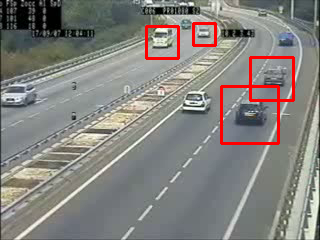

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

cap = cv2.VideoCapture('video.avi')
car_cascade = cv2.CascadeClassifier('cars.xml')

# Read a single frame and release capture
ret, frame = cap.read()
cap.release()

if not ret:
    print("Error: Could not read frame.")
    exit()

gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
cars = car_cascade.detectMultiScale(gray, 1.1, 1)

for (x, y, w, h) in cars:
    cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 0, 255), 2)

cv2_imshow(frame)
cv2.waitKey(0)
cv2.destroyAllWindows()

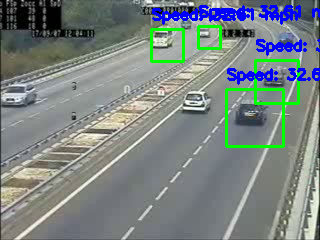

In [ ]:
import cv2
import numpy as np

# Start video capture
cap = cv2.VideoCapture('video.avi')
if not cap.isOpened():
    print("Error: Could not open video.")
    exit()

# Load the cascade classifier
car_cascade = cv2.CascadeClassifier('cars.xml')
if car_cascade.empty():
    print("Error: Could not load cascade classifier.")
    exit()

# Start tracker
tracker = cv2.TrackerKCF_create()

# Frame rate
fps = cap.get(cv2.CAP_PROP_FPS)
frame_interval = 1 / fps

# Read a single frame and release capture
ret, frame = cap.read()
cap.release()

if not ret:
    print("Error: Could not read frame.")
    exit()

gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
cars = car_cascade.detectMultiScale(gray, 1.1, 1)

# Start tracker for detected vehicles
tracked_vehicles = {}
current_id = 0
for (x, y, w, h) in cars:
    bbox = (x, y, w, h)
    tracker.init(frame, bbox)
    tracked_vehicles[current_id] = {0: bbox}
    current_id += 1

# Simulate a 'next frame' with slightly shifted positions for speed calculation
for vehicle_id in tracked_vehicles.keys():
    x, y, w, h = tracked_vehicles[vehicle_id][0]
    # Simulate movement
    shifted_x = x + 5
    shifted_y = y + 3
    tracked_vehicles[vehicle_id][1] = (shifted_x, shifted_y, w, h)

# Calculate and display speed
for vehicle_id, frames in tracked_vehicles.items():
    prev_bbox = frames[0]
    current_bbox = frames[1]

    # Compute pixel distance traveled
    dx = current_bbox[0] - prev_bbox[0]
    dy = current_bbox[1] - prev_bbox[1]
    pixel_distance = np.sqrt(dx**2 + dy**2)

    # Convert pixel distance to real-world distance
    real_world_distance_meters = pixel_distance * 0.1

    # Calculate speed in meters per second
    speed_mps = real_world_distance_meters / frame_interval

    # Convert speed to miles per hour
    speed_mph = speed_mps * 2.237

    cv2.rectangle(frame, (int(current_bbox[0]), int(current_bbox[1])),
                  (int(current_bbox[0] + current_bbox[2]), int(current_bbox[1] + current_bbox[3])),
                  (0, 255, 0), 2)

    cv2.putText(frame, f"Speed: {speed_mph:.2f} mph", (int(current_bbox[0]), int(current_bbox[1]) - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

from google.colab.patches import cv2_imshow
cv2_imshow(frame)
cv2.waitKey(0)
cv2.destroyAllWindows()